In [ ]:
# Importing necessary packages
from astroquery.utils.tap.core import TapPlus
import pandas as pd
import numpy as np
from astroquery.gaia import Gaia
import pyvo

In [ ]:
class ALL_SERVER:
    def check_gaia_server(self):
        try:
            job = Gaia.launch_job("SELECT TOP 1 * FROM gaiadr3.gaia_source")
            results = job.get_results()

            print("✅GAIA Server is up and responding properly!")
            print(f"✅Successfully retrieved {len(results)} row(s).")

        except Exception as e:
            print("❌GAIA Server is not responding")
            print(f"Error details: {e}")

    def check_vizier_server(self):
        url = "http://tapvizier.u-strasbg.fr/TAPVizieR/tap"
        print(f"Pinging {url}...")

        try:
            # Initialize connection
            vizier_tap = TapPlus(url=url)

            # Run the lightest possible query (just 1 row)
            job = vizier_tap.launch_job("SELECT TOP 1 * FROM \"I/355/gaiadr3\"")
            results = job.get_results()
            
            print("✅ VIZIER Server is UP and responding properly!")
            print(f"✅ Successfully retrieved {len(results)} row(s).")
            
        except Exception as e:
            print("❌ VIZIER Server appears to be DOWN or unreachable.")
            print(f"Error details: {e}")

    def check_aip_server(self):
        url = "https://gaia.aip.de/tap"
        print(f"Pinging {url}...")

        try:
            # Initialize connection using pyvo
            service = pyvo.dal.TAPService(url)
            
            # Run the lightest possible query (just 1 row)
            # Force the format parameter directly on execution to bypass strict header negotiation 
            # (asked by AIP server while using TapPlus)
            job = service.search("SELECT TOP 1 * FROM gaiadr3.gaia_source_lite", response_format='votable')
            
            print("✅ AIP (Potsdam) Server is UP and responding properly!")
            print(f"✅ Successfully retrieved {len(job)} row(s).")
 
        except Exception as e:
            print("❌ AIP Server appears to be DOWN or unreachable.")
            print(f"Error details: {e}")

    def check_ari_server(self):
        url = "https://gaia.ari.uni-heidelberg.de/tap"
        print(f"Pinging {url}...")

        try:
            # Initialize connection
            ari_tap = TapPlus(url=url)
            
            # Run the lightest possible query (just 1 row)
            job = ari_tap.launch_job("SELECT TOP 1 * FROM gaiadr3.gaia_source_lite")
            results = job.get_results()
            
            print("✅ ARI (Heidelberg) Server is UP and responding properly!")
            print(f"✅ Successfully retrieved {len(results)} row(s).")
            
        except Exception as e:
            print("❌ ARI Server appears to be DOWN or unreachable.")
            print(f"Error details: {e}")
        
    def check_all_server(self):
        self.check_gaia_server()
        print("\n")
        self.check_vizier_server()
        print("\n")
        self.check_aip_server()
        print("\n")
        self.check_ari_server()


In [55]:
ALL_SERVER().check_all_server()

✅GAIA Server is up and responding properly!
✅Successfully retrieved 1 row(s).


Pinging http://tapvizier.u-strasbg.fr/TAPVizieR/tap...
          DR3Name              RA_ICRS     ... e_DEJ2000 RADEcorJ2000
                                 deg       ...    mas                
--------------------------- -------------- ... --------- ------------
Gaia DR3 413908747095021952 19.27825045975 ...  4.416146      -0.3781
✅ VIZIER Server is UP and responding properly!
✅ Successfully retrieved 1 row(s).


Pinging https://gaia.aip.de/tap...
<DALResultsTable length=1>
     source_id      random_index ...                   pos                  
                                 ...                                        
       int64           int64     ...                  object                
------------------- ------------ ... ---------------------------------------
4049114812626097152    600253525 ... (4.74316085911001 , -0.546549509286791)
✅ AIP (Potsdam) Server is UP and responding properly!


In [20]:
def fetch_gaia_data_example():
    url = "http://tapvizier.u-strasbg.fr/TAPVizieR/tap"
    print(f"Connecting to {url}...")
    
    # Initialize connection
    vizier_tap = TapPlus(url=url)
    
    # Run a query to retrieve actual data (e.g., coordinates, parallax, and photometry)
    query = """
    SELECT TOP 1000 *
    FROM "I/355/gaiadr3"
    """
    
    print("Executing query...")
    job = vizier_tap.launch_job(query)
    results = job.get_results()
    
    # Convert the result to a Pandas DataFrame
    df = results.to_pandas()
    return  df

In [21]:
df_data = fetch_gaia_data_example()

Connecting to http://tapvizier.u-strasbg.fr/TAPVizieR/tap...
Executing query...


In [22]:
df_data.head()

,DR3Name,RA_ICRS,DE_ICRS,SolID,Source,RandomI,e_RA_ICRS,e_DE_ICRS,Plx,e_Plx,...,RAVE6,dRAVE6,f_RAVE6,RAVE6oid,nRAVE6,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000
0,Gaia DR3 413893255156526592,19.383391,58.498645,1636148068921376768,413893255156526592,155607965,0.3589,0.4306,1.2442,0.6302,...,,NaN,<NA>,NaN,<NA>,19.383402,58.498642,8.305945,10.799050,-0.2787
1,Gaia DR3 413893250855311616,19.388006,58.501322,1636148068921376768,413893250855311616,1205915279,0.0599,0.0765,0.2020,0.1134,...,,NaN,<NA>,NaN,<NA>,19.388016,58.501322,1.414486,1.798757,-0.2897
2,Gaia DR3 413893255156526080,19.385651,58.501436,1636148068921376768,413893255156526080,1294666989,0.3327,0.4404,0.7623,0.6232,...,,NaN,<NA>,NaN,<NA>,19.385665,58.501436,7.994923,12.195230,-0.3428
3,Gaia DR3 413893255156985216,19.385631,58.503443,1636148068921376768,413893255156985216,317751012,0.4235,0.5165,0.6830,0.7563,...,,NaN,<NA>,NaN,<NA>,19.385665,58.503449,9.547183,14.211628,-0.3989
4,Gaia DR3 413894728324076672,19.388826,58.510391,1636148068921376768,413894728324076672,777020754,0.0487,0.0615,0.0172,0.0892,...,,NaN,<NA>,NaN,<NA>,19.388825,58.510394,1.105139,1.416852,-0.4222


In [ ]:
query = """
SELECT TOP 1000
    source_id,
    ra,
    dec,
    parallax,
    phot_g_mean_mag,
    bp_rp,
    teff_gspphot
FROM gaiadr3.gaia_source
WHERE parallax IS NOT NULL 
AND teff_gspphot IS NOT NULL
AND parallax > 0
"""

job = Gaia.launch_job_async(query)
stars = job.get_results()
df = stars.to_pandas()

Due to scheduled ESAC network maintenance activities, the Archive may suffer short-time disconnections from Monday, 29 June 2026 at 18:00 CEST until Tuesday, 30 June 2026 at 00:00 CEST. We apologize for the inconvenience.
INFO: Query finished. [astroquery.utils.tap.core]


In [ ]:
df["mag"] = df["phot_g_mean_mag"] + 5 + 5 * np.log10(df["parallax"] / 1000)

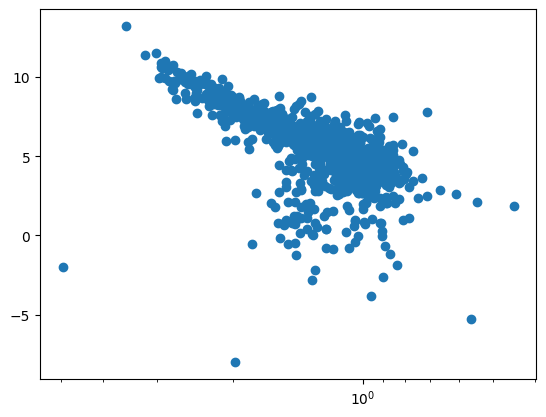

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

ax.xaxis.set_inverted(True)
ax.scatter(df["bp_rp"], df["lum"])
ax.set_xscale("log")
